# Vectors, Shapes and Norms

## Purpose

Understand how simple linear algebra vectors are represented in NumPy, and why shape matters.

Start by importing NumPy.

In [10]:
import numpy as np

## Plotting helpers

These helpers keep the plotting setup out of the learning examples.

In [11]:
import matplotlib.pyplot as plt


def setup_vector_plot(xlim=(-1, 6), ylim=(-1, 6)):
    """Create a simple 2D coordinate plane for vector diagrams."""
    plt.figure(figsize=(3, 3))
    plt.axhline(0)
    plt.axvline(0)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.gca().set_aspect("equal")
    plt.grid(True)


def draw_vector(
    vector,
    start=(0, 0),
    label=None,
    color=None,
    label_position="end",
    label_offset=(0.1, 0.1),
):
    """Draw a 2D vector as an arrow, with optional label."""
    start = np.array(start)
    vector = np.array(vector)
    end = start + vector

    plt.quiver(
        start[0],
        start[1],
        vector[0],
        vector[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=color,
    )

    if label:
        if label_position == "middle":
            label_point = start + 0.5 * vector
        else:  # default to end
            label_point = end

        plt.text(
            label_point[0] + label_offset[0],
            label_point[1] + label_offset[1],
            label,
        )

## A first vector

## Visualising a single vector

A 2D vector can be drawn as an arrow from the origin to the point represented by its components. I will use `v = [3, 4]` because it has an easy-to-check length: the 3-4-5 triangle.

The vector `[3, 4]` starts at `(0, 0)` and ends at `(3, 4)`.

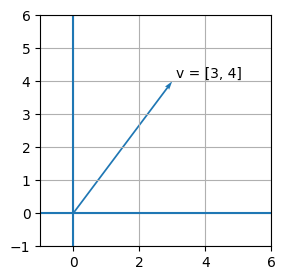

In [12]:
v = np.array([3, 4])

setup_vector_plot()
draw_vector(v, label="v = [3, 4]")
plt.show()

The arrow ends at `(3, 4)`. Its length is the norm of the vector, which is `5`.

In [13]:
print("Vector:", v)
print("Shape:", v.shape)
print("Norm:", np.linalg.norm(v))

Vector: [3 4]
Shape: (2,)
Norm: 5.0


The shape `(2,)` means this is a one-dimensional NumPy array with two elements. It is not a row matrix or a column matrix yet.

The norm is `5.0`, matching the 3-4-5 triangle. This gives a geometric interpretation of vector length.

## Visualising vector addition

Vector addition means adding matching components.

Geometrically, this can be shown by drawing the second vector starting at the end of the first vector.

In [14]:
a = np.array([1, 4])
b = np.array([2, -2])
a_plus_b = a + b

print("Vector a:", a)
print("Vector b:", b)
print("Vector a + b:", a_plus_b)

Vector a: [1 4]
Vector b: [ 2 -2]
Vector a + b: [3 2]


The result is `[3, 2]`, because NumPy adds the first components together (1 + 2) and the second components together (4 + (-2)).

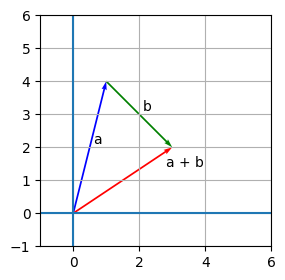

In [15]:
setup_vector_plot()

draw_vector(a, label="a", color="blue", label_position="middle")
draw_vector(b, start=a, label="b", color="green", label_position="middle")
draw_vector(a_plus_b, label="a + b", color="red", label_position="end", label_offset=(-0.2, -0.6))

plt.show()

The vector `a + b` reaches the same final point as moving first by `a`, then by `b`.

## Scalar multiplication

Multiplying a vector by a scalar changes its length while keeping the same direction, unless the scalar is negative.

In [16]:
2 * v

array([6, 8])

The vector `[3, 4]` becomes `[6, 8]`. Its direction is the same, but its length has doubled.

In [17]:
np.linalg.norm(v), np.linalg.norm(2 * v)

(np.float64(5.0), np.float64(10.0))

The norm doubles from `5.0` to `10.0`, which matches the geometric idea.

## Why this matters for ML

In machine learning, a vector often represents a row of features.

For example, a house could be represented as:

`[bedrooms, floor_area, distance_to_station]`

A model does not see “a house” directly. It sees numbers arranged as vectors.

In [18]:
house = np.array([3, 85, 1.2])
house.shape

(3,)

This is a three-feature vector. Later, many rows like this become a matrix.